[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/pytorch-mastery/blob/main/02_core_deep_learning/02_cnn/cnn.ipynb)


# 02 . Convolutional Neural Networks (CNNs)

## Concept — CNNs (revision notes)

**What it is**
- A network whose layers slide small learnable filters (kernels) over a grid-like input (images, spectrograms, 1D signals) instead of connecting every input to every output.
- Building blocks: `nn.Conv2d` (feature detectors), normalization (`nn.BatchNorm2d`), a nonlinearity, pooling (`nn.MaxPool2d`, `nn.AdaptiveAvgPool2d`) and a small `nn.Linear` head.

**Why it matters**
- **Weight sharing**: the same 3x3 filter is applied at every position, so parameter count does not grow with image size.
- **Locality**: nearby pixels are related, so each output looks only at a small neighbourhood (its *receptive field*); stacking layers grows the field.
- **Translation equivariance**: shift the input and the feature map shifts with it; pooling then turns this into (approximate) invariance. This is the prior that makes CNNs data-efficient on images.

**When to use**
- Images, audio spectrograms, 1D sensor signals, any data where a pattern means the same thing wherever it appears.
- Not ideal when global, long-range interactions dominate from layer one (attention-based models handle those better).

**Math & intuition**
- Output size: `out = floor((in + 2*padding - dilation*(k-1) - 1) / stride) + 1`.
- Parameters of `Conv2d(C_in, C_out, k)`: `C_out * C_in * k * k + C_out` - independent of H and W.
- Tensor layout in PyTorch is **NCHW**: (batch, channels, height, width).
- `nn.Conv2d` actually computes *cross-correlation* (no kernel flip); the distinction does not matter for learning.
- Receptive field grows by `(k-1) * (product of earlier strides)` per layer.
- A typical block is `Conv -> BatchNorm -> ReLU`, with `bias=False` in the conv because BN has its own shift.


### 1. A convolution by hand vs nn.Conv2d

**What this cell does (plain language):** we compute a 3x3 convolution with explicit Python loops, then again with `F.unfold` (which turns every patch into a column so convolution becomes one matrix multiply), and compare both against `nn.Conv2d`. If all three agree you have really understood what a convolution does: a dot product of the kernel with every local patch.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)

x = torch.randn(1, 1, 5, 5)                 # NCHW: one 5x5 single-channel image
conv = nn.Conv2d(1, 1, kernel_size=3, bias=False)
w = conv.weight                              # shape (C_out=1, C_in=1, 3, 3)

# (a) explicit loops: slide the kernel, take a dot product at each location
out_loop = torch.zeros(3, 3)
for i in range(3):
    for j in range(3):
        patch = x[0, 0, i:i+3, j:j+3]
        out_loop[i, j] = (patch * w[0, 0]).sum()

# (b) unfold: columns of patches (1, 9, 9) -> matmul with flattened kernel
patches = F.unfold(x, kernel_size=3)         # (N, C*k*k, L) with L = number of positions
out_unfold = (w.view(1, -1) @ patches).view(3, 3)

out_builtin = conv(x)[0, 0]
print("loop   == builtin:", torch.allclose(out_loop, out_builtin, atol=1e-6))
print("unfold == builtin:", torch.allclose(out_unfold, out_builtin, atol=1e-6))
print("input", tuple(x.shape), "-> output", tuple(conv(x).shape))

loop   == builtin: True
unfold == builtin: True
input (1, 1, 5, 5) -> output (1, 1, 3, 3)


### 2. Output shape: kernel, padding, stride, dilation

**What this cell does (plain language):** we sweep the hyper-parameters of a conv layer, print the resulting spatial size, and check each against the closed-form formula. Getting shapes right in your head is the most common practical CNN skill.

In [2]:
def out_size(n, k, p=0, s=1, d=1):
    return (n + 2*p - d*(k-1) - 1) // s + 1

x = torch.randn(1, 3, 32, 32)
configs = [
    dict(kernel_size=3),                           # shrinks by 2
    dict(kernel_size=3, padding=1),                # "same" size
    dict(kernel_size=3, padding=1, stride=2),      # halves
    dict(kernel_size=5, padding=2),                # "same" with bigger kernel
    dict(kernel_size=3, padding=2, dilation=2),    # dilated 3x3 covers a 5x5 area, "same"
    dict(kernel_size=7, stride=2, padding=3),      # ResNet-style stem
]
for cfg in configs:
    y = nn.Conv2d(3, 8, **cfg)(x)
    pred = out_size(32, cfg["kernel_size"], cfg.get("padding", 0), cfg.get("stride", 1), cfg.get("dilation", 1))
    print(f"{str(cfg):55s} -> {tuple(y.shape)}  formula says {pred}")
    assert y.shape[-1] == pred

# padding='same' is a convenience (stride must be 1)
print("padding='same':", tuple(nn.Conv2d(3, 8, 3, padding="same")(x).shape))

{'kernel_size': 3}                                      -> (1, 8, 30, 30)  formula says 30
{'kernel_size': 3, 'padding': 1}                        -> (1, 8, 32, 32)  formula says 32
{'kernel_size': 3, 'padding': 1, 'stride': 2}           -> (1, 8, 16, 16)  formula says 16
{'kernel_size': 5, 'padding': 2}                        -> (1, 8, 32, 32)  formula says 32
{'kernel_size': 3, 'padding': 2, 'dilation': 2}         -> (1, 8, 32, 32)  formula says 32
{'kernel_size': 7, 'stride': 2, 'padding': 3}           -> (1, 8, 16, 16)  formula says 16
padding='same': (1, 8, 32, 32)


### 3. Weight sharing: parameter counts, conv vs fully connected

**What this cell does (plain language):** we count parameters for a conv layer and (by formula) for a linear layer that maps the same input to the same-sized output. The conv count does not depend on image size; the linear count explodes. That gap is why CNNs exist.

In [3]:
def n_params(m): return sum(p.numel() for p in m.parameters())

conv = nn.Conv2d(3, 16, kernel_size=3, padding=1)
print("Conv2d(3,16,3) params:", n_params(conv), "= 16*3*3*3 + 16 =", 16*3*3*3 + 16)

for size in (16, 32, 64):
    # a dense layer producing the same (16, size, size) output from a (3, size, size) input
    # (formula only: actually allocating the 64x64 dense layer would need ~3 GB)
    dense_params = (3*size*size) * (16*size*size) + 16*size*size
    print(f"image {size:2d}x{size:2d}: conv params = {n_params(conv):5d} | dense params = {dense_params:>12,d}")

Conv2d(3,16,3) params: 448 = 16*3*3*3 + 16 = 448
image 16x16: conv params =   448 | dense params =    3,149,824
image 32x32: conv params =   448 | dense params =   50,348,032
image 64x64: conv params =   448 | dense params =  805,371,904


### 4. A synthetic image dataset (shapes at random positions)

**What this cell does (plain language):** there is no internet, so we generate 16x16 images that each contain one 5x5 pattern (box, plus, X or filled square) at a random location, plus noise. The class is *what* the shape is, never *where* it is, which is exactly the situation where convolutions shine. We also hold out a test set.

train (800, 1, 16, 16) test (400, 1, 16, 16) class counts: [212, 190, 207, 191]


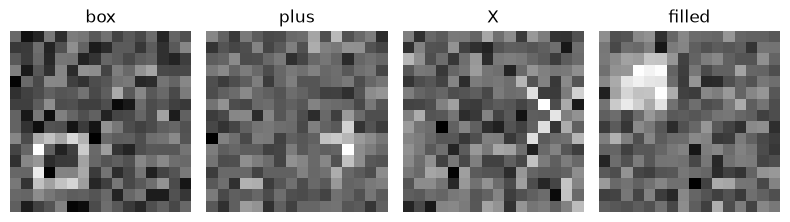

In [4]:
def make_patterns():
    b = torch.zeros(5, 5); b[0, :] = b[-1, :] = 1; b[:, 0] = b[:, -1] = 1       # box outline
    p = torch.zeros(5, 5); p[2, :] = 1; p[:, 2] = 1                               # plus
    x_ = torch.eye(5) + torch.eye(5).flip(1); x_ = x_.clamp(max=1)               # X
    f = torch.ones(5, 5)                                                          # filled square
    return torch.stack([b, p, x_, f])                                             # (4, 5, 5)

PATTERNS = make_patterns()
CLASSES = ["box", "plus", "X", "filled"]

def make_dataset(n, seed, size=16, noise=0.3):
    g = torch.Generator().manual_seed(seed)
    labels = torch.randint(0, 4, (n,), generator=g)
    imgs = torch.randn(n, 1, size, size, generator=g) * noise
    for i in range(n):
        r, c = torch.randint(0, size - 5 + 1, (2,), generator=g).tolist()
        imgs[i, 0, r:r+5, c:c+5] += PATTERNS[labels[i]]
    return imgs, labels

Xtr, ytr = make_dataset(800, seed=1)
Xte, yte = make_dataset(400, seed=2)
print("train", tuple(Xtr.shape), "test", tuple(Xte.shape), "class counts:", torch.bincount(ytr).tolist())

fig, axes = plt.subplots(1, 4, figsize=(8, 2.2))
for k, ax in enumerate(axes):
    idx = (ytr == k).nonzero()[0].item()
    ax.imshow(Xtr[idx, 0], cmap="gray"); ax.set_title(CLASSES[k]); ax.axis("off")
plt.tight_layout(); plt.show()

### 5. A small CNN (Conv-BN-ReLU-Pool) and a training function

**What this cell does (plain language):** we define a reusable `train_eval` helper and a small CNN that ends in `AdaptiveAvgPool2d(1)` (global average pooling) so the classifier head does not depend on image size. We train it and report test accuracy.

In [5]:
from torch.utils.data import TensorDataset, DataLoader

def conv_block(cin, cout):
    # bias=False because BatchNorm already has a learnable shift
    return nn.Sequential(nn.Conv2d(cin, cout, 3, padding=1, bias=False),
                         nn.BatchNorm2d(cout), nn.ReLU(), nn.MaxPool2d(2))

class SmallCNN(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()
        self.features = nn.Sequential(conv_block(1, 8), conv_block(8, 16))   # 16 -> 8 -> 4
        self.pool = nn.AdaptiveAvgPool2d(1)                                  # (N,16,4,4) -> (N,16,1,1)
        self.head = nn.Linear(16, n_classes)
    def forward(self, x):
        return self.head(self.pool(self.features(x)).flatten(1))

def accuracy(model, X, y):
    model.eval()                                   # BN uses running stats, not batch stats
    with torch.no_grad():
        return (model(X).argmax(1) == y).float().mean().item()

def train_eval(model, epochs=15, lr=3e-3, X=Xtr, y=ytr, verbose=True):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(X, y), batch_size=64, shuffle=True,
                        generator=torch.Generator().manual_seed(0))
    for ep in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad(); loss = F.cross_entropy(model(xb), yb); loss.backward(); opt.step()
        if verbose and (ep % 5 == 4 or ep == 0):
            print(f"epoch {ep+1:2d}  last-batch loss {loss.item():.3f}  test acc {accuracy(model, Xte, yte):.3f}")
    return model

torch.manual_seed(0)
cnn = train_eval(SmallCNN())
print("params:", n_params(cnn))

epoch  1  last-batch loss 1.222  test acc 0.377


epoch  5  last-batch loss 0.764  test acc 0.895


epoch 10  last-batch loss 0.408  test acc 0.947


epoch 15  last-batch loss 0.250  test acc 0.965
params: 1340


### 6. CNN vs MLP: the value of the translation prior

**What this cell does (plain language):** we train a plain MLP on the flattened pixels with a comparable parameter budget and compare it to the CNN on the same data. The MLP must learn every shape separately at every position, so with only 800 examples it has far less to go on than the CNN.

In [6]:
torch.manual_seed(0)
mlp = nn.Sequential(nn.Flatten(), nn.Linear(256, 64), nn.ReLU(), nn.Linear(64, 4))
print("MLP params:", n_params(mlp), "| CNN params:", n_params(cnn))
train_eval(mlp, verbose=False)
print(f"MLP test acc: {accuracy(mlp, Xte, yte):.3f}   CNN test acc: {accuracy(cnn, Xte, yte):.3f}")
print("MLP train acc:", round(accuracy(mlp, Xtr, ytr), 3), "(compare to its test acc to see the overfitting gap)")

MLP params: 16708 | CNN params: 1340


MLP test acc: 0.458   CNN test acc: 0.965
MLP train acc: 1.0 (compare to its test acc to see the overfitting gap)


### 7. Equivariance vs invariance, measured

**What this cell does (plain language):** a convolution *feature map* should shift when the input shifts (equivariance), while the final *prediction* should stay the same (invariance, thanks to global pooling). We shift test images with `torch.roll` and check both properties directly on the network. Neither is exact: padding, wrap-around from `roll`, and max-pool alignment all break perfect equivariance, so read the numbers as 'approximately'.

In [7]:
cnn.eval()
img = Xte[:8]
shift = 4                                   # pixels (a multiple of the total stride 4 keeps pooling aligned)
shifted = torch.roll(img, shifts=(0, shift), dims=(2, 3))

with torch.no_grad():
    f1 = cnn.features(img)                  # (8, 16, 4, 4)
    f2 = cnn.features(shifted)
    # equivariance: shifting input by 4 px shifts the 4x downsampled map by 1 cell
    f1_shift = torch.roll(f1, shifts=1, dims=3)
    interior = slice(1, 4)                  # ignore wrapped border columns (padding/roll edge effects)
    err = (f1_shift[..., interior] - f2[..., interior]).abs().mean().item()
    print("mean |shift(features(x)) - features(shift(x))| (interior):", round(err, 4),
          "| typical feature magnitude:", round(f1.abs().mean().item(), 4))
    same = (cnn(img).argmax(1) == cnn(shifted).argmax(1)).float().mean().item()
print("prediction unchanged after shift for fraction:", same)
print("(for an MLP on raw pixels, a shift changes every input value, so no such property exists)")

mean |shift(features(x)) - features(shift(x))| (interior): 0.1847 | typical feature magnitude: 1.0775
prediction unchanged after shift for fraction: 0.75
(for an MLP on raw pixels, a shift changes every input value, so no such property exists)


### 8. Receptive field and what filters/feature maps look like

**What this cell does (plain language):** we compute the theoretical receptive field of a conv stack with a tiny recurrence, then plot the first-layer learned filters and the feature maps for one image. With so few filters and such a simple task, the learned filters look noisy rather than like textbook edge detectors; what matters is that each feature map responds differently to different parts of the shape. Deeper maps are coarser (lower resolution, larger receptive field).

3x3 s1 x3          : 7 (three 3x3 convs see 7x7, like one 7x7 conv but with fewer params)
conv3,pool2,conv3,pool2: 10
our SmallCNN       : 10 of a 16x16 image


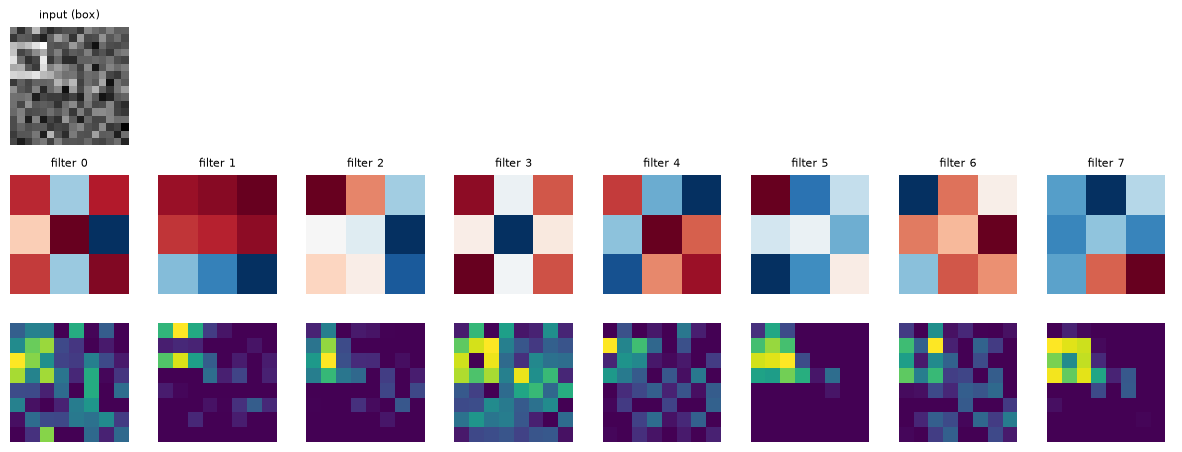

In [8]:
def receptive_field(layers):
    """layers: list of (kernel, stride). Returns RF size of one output unit."""
    rf, jump = 1, 1
    for k, s in layers:
        rf += (k - 1) * jump     # each layer adds (k-1) * (distance between adjacent units so far)
        jump *= s
    return rf

print("3x3 s1 x3          :", receptive_field([(3,1)]*3), "(three 3x3 convs see 7x7, like one 7x7 conv but with fewer params)")
print("conv3,pool2,conv3,pool2:", receptive_field([(3,1),(2,2),(3,1),(2,2)]))
print("our SmallCNN       :", receptive_field([(3,1),(2,2),(3,1),(2,2)]), "of a 16x16 image")

w1 = cnn.features[0][0].weight.detach()            # (8, 1, 3, 3)
sample = Xte[0:1]
with torch.no_grad():
    fm1 = cnn.features[0](sample)[0]               # after block 1: (8, 8, 8)
fig, axes = plt.subplots(3, 8, figsize=(12, 4.6))
axes[0, 0].imshow(sample[0, 0], cmap="gray"); axes[0, 0].set_title(f"input ({CLASSES[yte[0]]})", fontsize=8)
for i in range(8):
    axes[1, i].imshow(w1[i, 0], cmap="RdBu"); axes[1, i].set_title(f"filter {i}", fontsize=8)
    axes[2, i].imshow(fm1[i], cmap="viridis")
for ax in axes.ravel(): ax.axis("off")
plt.tight_layout(); plt.show()

### 9. Pooling variants and size-agnostic heads

**What this cell does (plain language):** we compare max, average and adaptive pooling on a tiny tensor, and then feed images of a *different* size through the trained CNN. Because the head uses global average pooling the network accepts any size; a `Flatten + Linear` head would crash.

In [9]:
t = torch.tensor([[[[1., 2., 5., 6.],
                    [3., 4., 7., 8.],
                    [0., 0., 1., 1.],
                    [0., 2., 1., 3.]]]])
print("max pool 2x2:\n", F.max_pool2d(t, 2)[0, 0])
print("avg pool 2x2:\n", F.avg_pool2d(t, 2)[0, 0])
print("adaptive avg pool to 1x1 (global average):", F.adaptive_avg_pool2d(t, 1).item(), "| mean:", t.mean().item())

# size-agnostic: train on 16x16, evaluate on 24x24 canvases with the same 5x5 shapes
Xbig, ybig = make_dataset(200, seed=3, size=24)
print("accuracy on 24x24 images (never trained on this size):", round(accuracy(cnn, Xbig, ybig), 3))

flat_head = nn.Sequential(cnn.features, nn.Flatten(), nn.Linear(16*4*4, 4))
try:
    flat_head(Xbig)
except RuntimeError as e:
    print("Flatten+Linear head on 24x24 ->", str(e)[:70], "...")

max pool 2x2:
 tensor([[4., 8.],
        [2., 3.]])
avg pool 2x2:
 tensor([[2.5000, 6.5000],
        [0.5000, 1.5000]])
adaptive avg pool to 1x1 (global average): 2.75 | mean: 2.75
accuracy on 24x24 images (never trained on this size): 0.635
Flatten+Linear head on 24x24 -> mat1 and mat2 shapes cannot be multiplied (200x576 and 256x4) ...


### 10. Efficiency tricks: 1x1 conv, depthwise-separable conv, residual block

**What this cell does (plain language):** we implement three ideas used in nearly every modern CNN: a 1x1 convolution (mixes channels only), a depthwise-separable convolution (spatial and channel mixing split apart for far fewer parameters), and a residual block (`x + f(x)`). Parameter counts are printed so the savings are concrete.

In [10]:
cin, cout = 64, 128
standard = nn.Conv2d(cin, cout, 3, padding=1)
depthwise_sep = nn.Sequential(
    nn.Conv2d(cin, cin, 3, padding=1, groups=cin),   # depthwise: one 3x3 filter per channel
    nn.Conv2d(cin, cout, 1))                          # pointwise: 1x1 mixes channels
print("standard 3x3 conv params      :", n_params(standard))
print("depthwise-separable params    :", n_params(depthwise_sep))
x = torch.randn(2, cin, 8, 8)
print("same output shape:", standard(x).shape == depthwise_sep(x).shape)

class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.body = nn.Sequential(nn.Conv2d(c, c, 3, padding=1, bias=False), nn.BatchNorm2d(c), nn.ReLU(),
                                  nn.Conv2d(c, c, 3, padding=1, bias=False), nn.BatchNorm2d(c))
    def forward(self, x):
        return F.relu(x + self.body(x))               # skip connection: gradient has a direct path back

rb = ResBlock(16)
print("ResBlock keeps shape:", tuple(rb(torch.randn(2, 16, 8, 8)).shape))

standard 3x3 conv params      : 73856
depthwise-separable params    : 8960
same output shape: True
ResBlock keeps shape: (2, 16, 8, 8)


### 11. Data augmentation with plain tensor ops

**What this cell does (plain language):** real image pipelines use random flips and shifts to expand the effective dataset. Without torchvision we do it with `torch.roll`/`flip` applied per batch, then retrain on a much smaller training set (100 images) with and without augmentation to see the regularizing effect.

In [11]:
def augment(xb):
    # random circular shift of up to 3 px in each direction, plus random horizontal flip
    dy, dx = torch.randint(-3, 4, (2,)).tolist()
    xb = torch.roll(xb, shifts=(dy, dx), dims=(2, 3))
    if torch.rand(()) < 0.5:
        xb = xb.flip(3)
    return xb

def train_small(use_aug, seed=0, epochs=30):
    torch.manual_seed(seed)
    m = SmallCNN(); opt = torch.optim.Adam(m.parameters(), lr=3e-3)
    Xs, ys = Xtr[:100], ytr[:100]
    for ep in range(epochs):
        m.train()
        perm = torch.randperm(100)
        for i in range(0, 100, 20):
            idx = perm[i:i+20]; xb = Xs[idx]
            if use_aug: xb = augment(xb)
            opt.zero_grad(); F.cross_entropy(m(xb), ys[idx]).backward(); opt.step()
    return accuracy(m, Xte, yte)

print("100 training images, no augmentation  -> test acc:", round(train_small(False), 3))
print("100 training images, with augmentation -> test acc:", round(train_small(True), 3))
print("(on this toy task the two may be close; the point is the mechanics. Flips are only valid if labels survive them!)")

100 training images, no augmentation  -> test acc: 0.902


100 training images, with augmentation -> test acc: 0.918
(on this toy task the two may be close; the point is the mechanics. Flips are only valid if labels survive them!)


## Common bugs

- **Wrong tensor layout (NHWC vs NCHW)**
  Feeding `(N, H, W, C)` arrays (NumPy/PIL/matplotlib convention) to `Conv2d` fails with a channel mismatch, or worse silently treats width as channels. Fix: `x.permute(0, 3, 1, 2)` before the model; permute back for plotting.

- **Missing the batch dimension**
  `Conv2d` wants 4D `(N, C, H, W)`. A single image `(C, H, W)` is accepted in new versions as unbatched but then `BatchNorm`/`Flatten(1)` behave unexpectedly. Fix: `img.unsqueeze(0)` for a batch of one.

- **Hard-coded `Linear` input size after the conv stack**
  Changing the image size or adding a pooling layer breaks `nn.Linear(16*4*4, ...)` with a shape mismatch. Fix: use `AdaptiveAvgPool2d(1)` before the head, or compute the size by passing a dummy tensor through the feature extractor.

- **Forgetting `model.eval()` at test time**
  BatchNorm keeps using per-batch statistics (and updating running stats) so predictions depend on batch composition and are noisy. Fix: `model.eval()` plus `torch.no_grad()` for evaluation; call `model.train()` again before training.

- **Conv bias together with BatchNorm**
  Not an error, but `Conv2d(bias=True)` followed by BN wastes parameters, because BN subtracts the mean and adds its own shift. Fix: `bias=False` in the conv.

- **Pooling too early / too aggressively**
  Downsampling a 16x16 input to 1x1 after two blocks throws away the spatial detail the later layers need. Fix: downsample gradually and check the receptive field against the object size.

- **Augmentations that change the label**
  Horizontal-flipping digits or text, or rotating 6 into 9, silently corrupts labels. Fix: only apply transformations that your task is invariant to, and visualize augmented samples.

- **Applying augmentation to validation/test data**
  Test metrics become noisy and not comparable between runs. Fix: random augmentation on the training split only; deterministic preprocessing (normalization) on both.

- **Normalization statistics from the wrong split**
  Computing mean/std on train+test leaks information; using different stats at test time breaks the model. Fix: compute from the training set only and reuse them everywhere.


## Exercises

Attempt each one in the empty cell right after the question. A full solution is in the cell after that - don't peek until you've tried.

**Exercise 1 - Output shape arithmetic.**
Without running code, compute the output spatial size of `Conv2d(k=5, stride=2, padding=1)` on a 28x28 input, then verify with PyTorch.

In [12]:
# Your attempt for Exercise 1 here


**Solution 1**

In [13]:
# Solution 1
x = torch.randn(1, 1, 28, 28)
by_formula = (28 + 2*1 - 1*(5-1) - 1)//2 + 1
print(by_formula, nn.Conv2d(1, 1, 5, stride=2, padding=1)(x).shape)

13 torch.Size([1, 1, 13, 13])


**Exercise 2 - Count parameters.**
How many parameters does `nn.Conv2d(16, 32, 3)` have? Compute by formula and confirm with code.

In [14]:
# Your attempt for Exercise 2 here


**Solution 2**

In [15]:
# Solution 2
m = nn.Conv2d(16, 32, 3)
print("formula:", 32*16*3*3 + 32, "| actual:", sum(p.numel() for p in m.parameters()))

formula: 4640 | actual: 4640


**Exercise 3 - Edge detector kernel.**
Hand-set a Sobel kernel in a `Conv2d` (no bias, no training) and run it on an image with a vertical edge. Where is the response large?

In [16]:
# Your attempt for Exercise 3 here


**Solution 3**

In [17]:
# Solution 3
img = torch.zeros(1, 1, 8, 8); img[..., 4:] = 1.0        # left half dark, right half bright
conv = nn.Conv2d(1, 1, 3, bias=False)
with torch.no_grad():
    conv.weight.copy_(torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]]).view(1, 1, 3, 3))
print(conv(img)[0, 0].detach())    # large values only in the columns around the edge

tensor([[0., 0., 4., 4., 0., 0.],
        [0., 0., 4., 4., 0., 0.],
        [0., 0., 4., 4., 0., 0.],
        [0., 0., 4., 4., 0., 0.],
        [0., 0., 4., 4., 0., 0.],
        [0., 0., 4., 4., 0., 0.]])


**Exercise 4 - Receptive field of a stack.**
Three layers: conv3 stride1, conv3 stride2, conv3 stride1. What is the receptive field? Use the `receptive_field` helper from section 8 and verify by hand.

In [18]:
# Your attempt for Exercise 4 here


**Solution 4**

In [19]:
# Solution 4
print(receptive_field([(3,1),(3,2),(3,1)]))   # 1+2 -> 3, +2*1 -> 5, +2*2 -> 9

9


**Exercise 5 - Make the CNN size-agnostic.**
Replace `AdaptiveAvgPool2d(1)` in `SmallCNN` with `Flatten` + a `Linear` sized for 16x16 and show it fails on 24x24 input, then fix it with adaptive pooling to a fixed `(2,2)` grid.

In [20]:
# Your attempt for Exercise 5 here


**Solution 5**

In [21]:
# Solution 5
class FixedGrid(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(conv_block(1, 8), conv_block(8, 16))
        self.pool = nn.AdaptiveAvgPool2d((2, 2))      # always 2x2 regardless of input size
        self.head = nn.Linear(16*2*2, 4)
    def forward(self, x): return self.head(self.pool(self.features(x)).flatten(1))
print(FixedGrid()(torch.randn(2, 1, 16, 16)).shape, FixedGrid()(torch.randn(2, 1, 24, 24)).shape)

torch.Size([2, 4]) torch.Size([2, 4])


**Exercise 6 - Depthwise-separable savings.**
Compute the ratio of parameters between a standard 3x3 conv and its depthwise-separable version for `cin=cout=32`, ignoring biases.

In [22]:
# Your attempt for Exercise 6 here


**Solution 6**

In [23]:
# Solution 6
cin = cout = 32
std = cout*cin*9; sep = cin*9 + cin*cout
print(std, sep, round(std/sep, 2), "x fewer")

9216 1312 7.02 x fewer


**Exercise 7 - BatchNorm train vs eval.**
Show that in train mode the output of `BatchNorm2d` for a batch has ~zero mean per channel, but in eval mode (fresh running stats) it does not.

In [24]:
# Your attempt for Exercise 7 here


**Solution 7**

In [25]:
# Solution 7
bn = nn.BatchNorm2d(3)
x = torch.randn(16, 3, 8, 8) * 4 + 5
bn.train(); print("train mean:", bn(x).mean((0, 2, 3)).detach())
bn.eval();  print("eval mean :", bn(x).mean((0, 2, 3)).detach(), "(running stats not yet adapted)")

train mean: tensor([-6.9849e-08, -3.4692e-08,  3.8184e-08])
eval mean : tensor([2.7869, 2.7496, 2.8296]) (running stats not yet adapted)
